In [1]:
# === Core Utilities ===
import os
import logging
from collections import defaultdict
from typing import Tuple, List, Dict, Optional

# === Date/Time Handling ===
from datetime import datetime
# import datetime as dt  # Optional: alias if dt.datetime(...) is preferred

# === Numerical and Data Tools ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xc
import xskillscore as xs

# === Math & Signal Processing ===
import metpy.calc as mpcalc
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt, sosfilt, lfilter
from skimage.feature import peak_local_max

# === Plotting ===
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker

# === Mapping and Projections ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

# === Custom Color Maps and Visualization Tools ===
import cmaps as gvcmaps
import geocat.viz as gv
import geocat.viz.util as gvutil

# === Domain-Specific Toolkits ===
from tropycal import tracks, utils

from DartObsDiagUtil import DartObsDiagReader, ObsDiagPlotter

# === Suppress warnings globally ===
import warnings

/qfs/people/zhan391/.conda/envs/e3sm_analysis/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def get_dart_config(exp_name: str = None) -> dict:
    """
    Returns the full DART diagnostic configuration including global settings
    and experiment-specific metadata.

    Parameters
    ----------
    exp_name : str, optional
        Specific experiment to extract (e.g., 'DARTEN10'). If None, return all experiments.

    Returns
    -------
    dict
        Combined configuration dictionary with 'global' and 'experiments' keys.
    """
    config = {
        'global': {
            'case_name': 'JAN2011',
            'resolution': "F20TR_ne30pg2_r05_IcoswISC30E3r5",
            'machine': "compy",
            'diag_key': "obs_diag_output",
            'frequency': "6hourly",
            'region': 'Northern Hemisphere',
            'path_template': "/compyfs/zhan391/v3_dart_cda_scratch/%(RUNNAME)/archive/%(CASENAME)/dart_diagnostics/%(DIAG)",
            'file_template': "%(RUNNAME)_%(RES)_%(MACH).dart.e.eam_%(KEY).%(TIME).nc"
        },
        'experiments': {
            'CTRLEN10': {
                'run': 'CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en10',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'closest_member',
                'period': '2011121600-2012010100',
            },
            'DARTEN10': {
                'run': 'DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en10',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'closest_member',
                'period': '2011121600-2012122800',
            },
            'DARTEN20': {
                'run': 'DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en20',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'closest_member',
                'period': '2011121600-2012010100',
            },
            'DARTEN40': {
                'run': 'DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy',
                'key': 'dart_en40',
                'diag1': 'obs_seq',
                'diag2': 'obs_diag',
                'diag3': 'closest_member',
                'period': '2011121600-2012010100',
            }
        }
    }

    # If a specific experiment is requested, filter
    if exp_name:
        exps = config['experiments']
        config['experiments'] = {exp_name: exps[exp_name]} if exp_name in exps else {}

    return config

In [3]:
def build_ts_var_dict(var_key: str = None, name: str = None, 
                      y1aix: list = None, y1aix0: list = None) -> dict:
    """
    Build a single-entry variable dictionary for DART time series diagnostics.

    Parameters
    ----------
    var_key : str, optional
        Dictionary key name for the variable (e.g., 'AIRCRAFT_V').
        Defaults to 'RADIOSONDE_U' if not provided.
    name : str, optional
        Observation variable name (e.g., 'AIRCRAFT_V_WIND_COMPONENT').
        Defaults to 'RADIOSONDE_U_WIND_COMPONENT' if not provided.
    y1aix : list of float, optional
        Y-axis range for spread/RMSE plot.
    y1aix0 : list of float, optional
        Y-axis range for background spread/RMSE plot.

    Returns
    -------
    dict
        Dictionary with a single variable configuration.
    """
    var_key = var_key or 'RADIOSONDE_U'
    name = name or 'RADIOSONDE_U_WIND_COMPONENT'

    entry = {
        'name': name,
        'lev_type': 'pressure',
        'CopySpread': 'totalspread',
        'CopyRMSE': 'rmse',
        'CopyNposs': 'Nposs',
        'CopyNused': 'Nused',
        'type1': 'guess',
        'type2': 'VPguess',
        'type3': 'guess_RankHist',
        'y1aix': y1aix if y1aix is not None else [0, 10],
        'y2aix': [0, 100],
        'y1aix0': y1aix0 if y1aix0 is not None else [0, 10],
        'y2aix0': [0, 100],
    }

    return {var_key: entry}

In [4]:
def check_flat_lev_consistency(lev_dict):
    """
    Check whether all lev_dict[var] lists are identical across variables.

    Returns:
        reference_lev (list): The common pressure level list.

    Raises:
        ValueError: If any inconsistency is found.
    """
    ref_var = next(iter(lev_dict))
    reference = lev_dict[ref_var]

    for var, lev in lev_dict.items():
        if lev != reference:
            raise ValueError(
                f"Inconsistent pressure level list for variable '{var}'.\n"
                f"Expected: {reference}\n"
                f"Found:    {lev}"
            )

    print("All level lists are consistent across variables.")
    return reference

In [5]:
def compute_experiment_means(data_dict, diagnostic_keys_to_average):
    """
    Compute the mean of selected diagnostic keys across variables per experiment.
    For other keys, check consistency across variables: if all values match, use it;
    otherwise, raise an error.

    Returns:
        mean_dict[exp][diagnostic_key] = mean_array or consistent value.
    """

    # Sample to determine experiments and all diagnostic keys
    sample_var_data = next(iter(data_dict.values()))
    experiments = list(sample_var_data.keys())
    all_diagnostic_keys = next(iter(sample_var_data.values())).keys()

    mean_dict = {}

    for exp in experiments:
        mean_dict[exp] = {}

        for key in all_diagnostic_keys:
            if key in diagnostic_keys_to_average:
                # Average over variables
                valid_data = []
                for var in data_dict:
                    print(f"collect {exp} {key} {var}")
                    entry = data_dict[var].get(exp, {}).get(key, None)
                    if (
                        isinstance(entry, np.ndarray)
                        and entry.size > 0
                        and not np.all(np.isnan(entry))
                    ):
                        valid_data.append(entry)

                if valid_data:
                    try:
                        stacked = np.stack(valid_data, axis=0)
                        mean_array = np.nanmean(stacked, axis=0)
                    except ValueError:
                        shapes = [arr.shape for arr in valid_data]
                        print(f"[WARN] Shape mismatch for '{key}' in '{exp}': shapes = {shapes}. Skipping mean.")
                        mean_array = None
                else:
                    mean_array = None

                mean_dict[exp][key] = mean_array

            else:
                # For non-averaged keys, check consistency
                values = [
                    data_dict[var][exp][key]
                    for var in data_dict
                    if exp in data_dict[var] and key in data_dict[var][exp]
                ]
                if not values:
                    mean_dict[exp][key] = None
                    continue

                first_val = values[0]
                if all(np.array_equal(first_val, v) for v in values):
                    mean_dict[exp][key] = first_val
                else:
                    raise ValueError(
                        f"Inconsistent values for diagnostic key '{key}' in experiment '{exp}'."
                    )

    return mean_dict

found match for variable U_WIND in Conventional: RADIOSONDE_U_WIND_COMPONENT
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012122800.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_diag/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dar

/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)


Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
found match for variable U_WIND in Conventional: ACARS_U_WIND_COMPONENT
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012122800.nc


/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)


Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_diag/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
All level lists are consistent across variables.
collect CTRLEN10 rmse RADIOSONDE_U_WIND_COMPONENT
collect CTRLEN10 rmse DROPSONDE_U_WIND_COMPONENT
collect CTRLEN10 rmse AIRCRAFT_U_WIND_COMPONENT
collect CTRLEN10 rmse ACARS_U_WIND_COMPONENT
collect CTRLEN10 spread RADIOSONDE_U_WIND_COMPONENT
collect CTRLEN10 spread DROPSONDE_U_WIND_COMPONENT
collect CTRLEN10 spread AIRCRAFT_U_WIND_COMPONENT
collect CTRLEN10 spread ACARS_U_WIND_COMPONENT
collect CTRLEN10 rejection RADIOSONDE_U_WIND_COMPONENT
collect CTRLEN10 r

...

/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)


All level lists are consistent across variables.
collect CTRLEN10 rmse TEMPERATURE
collect CTRLEN10 rmse RADIOSONDE_TEMPERATURE
collect CTRLEN10 rmse DROPSONDE_TEMPERATURE
collect CTRLEN10 rmse AIRCRAFT_TEMPERATURE
collect CTRLEN10 rmse ACARS_TEMPERATURE
collect CTRLEN10 spread TEMPERATURE
collect CTRLEN10 spread RADIOSONDE_TEMPERATURE
collect CTRLEN10 spread DROPSONDE_TEMPERATURE
collect CTRLEN10 spread AIRCRAFT_TEMPERATURE
collect CTRLEN10 spread ACARS_TEMPERATURE
collect CTRLEN10 rejection TEMPERATURE
collect CTRLEN10 rejection RADIOSONDE_TEMPERATURE
collect CTRLEN10 rejection DROPSONDE_TEMPERATURE
collect CTRLEN10 rejection AIRCRAFT_TEMPERATURE
collect CTRLEN10 rejection ACARS_TEMPERATURE
collect DARTEN10 rmse TEMPERATURE
collect DARTEN10 rmse RADIOSONDE_TEMPERATURE
collect DARTEN10 rmse DROPSONDE_TEMPERATURE
collect DARTEN10 rmse AIRCRAFT_TEMPERATURE
collect DARTEN10 rmse ACARS_TEMPERATURE
collect DARTEN10 spread TEMPERATURE
collect DARTEN10 spread RADIOSONDE_TEMPERATURE
collect D

/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)
/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/2_obs_diagnostics/DartObsDiagUtil.py:123: RuntimeWarning: invalid value encountered in divide
  rejection = np.where(npos > 0, 100.0 - (nuse * 100.0 / npos), np.nan)


Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en20/dart_diagnostics/obs_diag/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/obs_diag/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
found match for variable Humidity in Conventional: DROPSONDE_SPECIFIC_HUMIDITY
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2011121600-2012010100.nc
Reading file: /compyfs/zhan391/v3_dart_cda_scratch/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en10/dart_diagnostics/obs_diag/DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.d

/tmp/ipykernel_203573/2523694647.py:38: RuntimeWarning: Mean of empty slice
  mean_array = np.nanmean(stacked, axis=0)


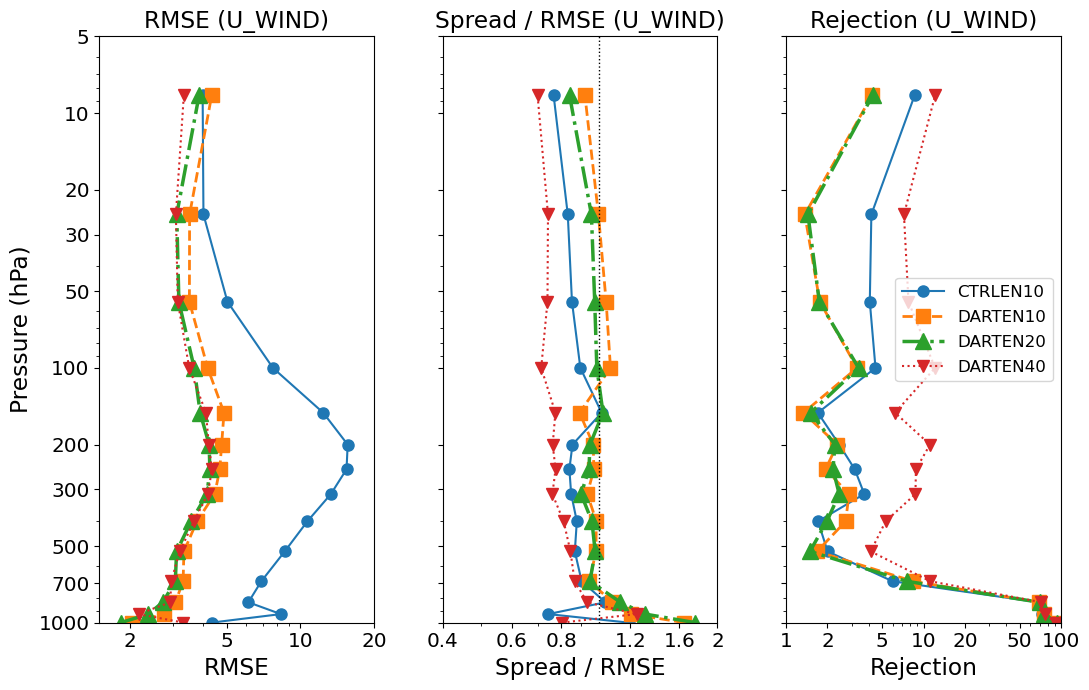

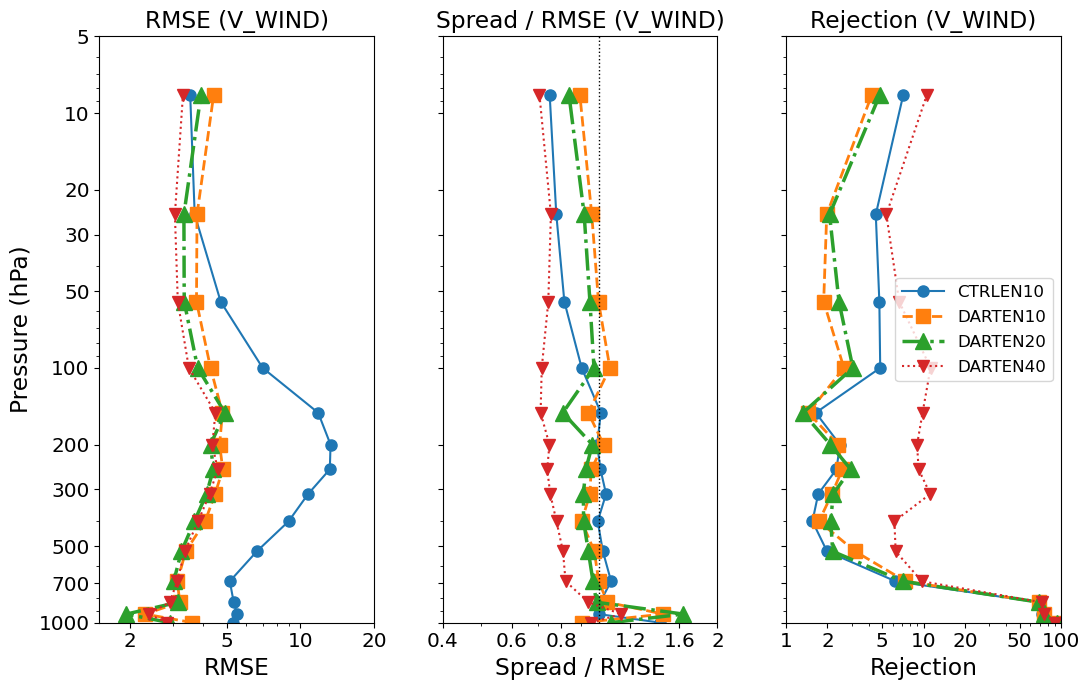

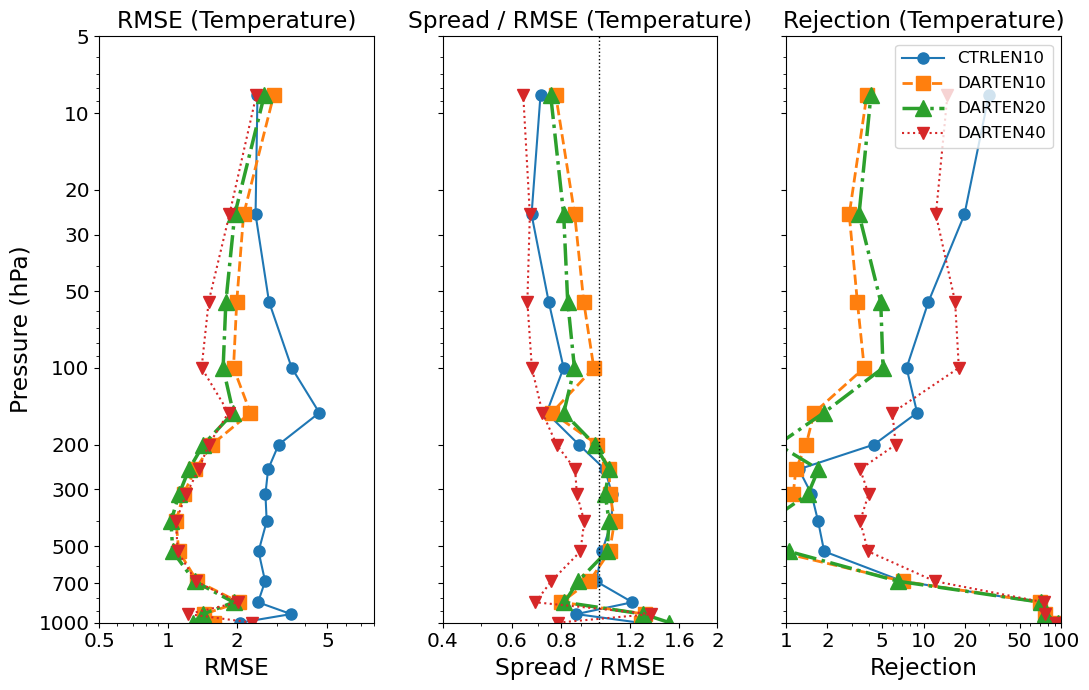

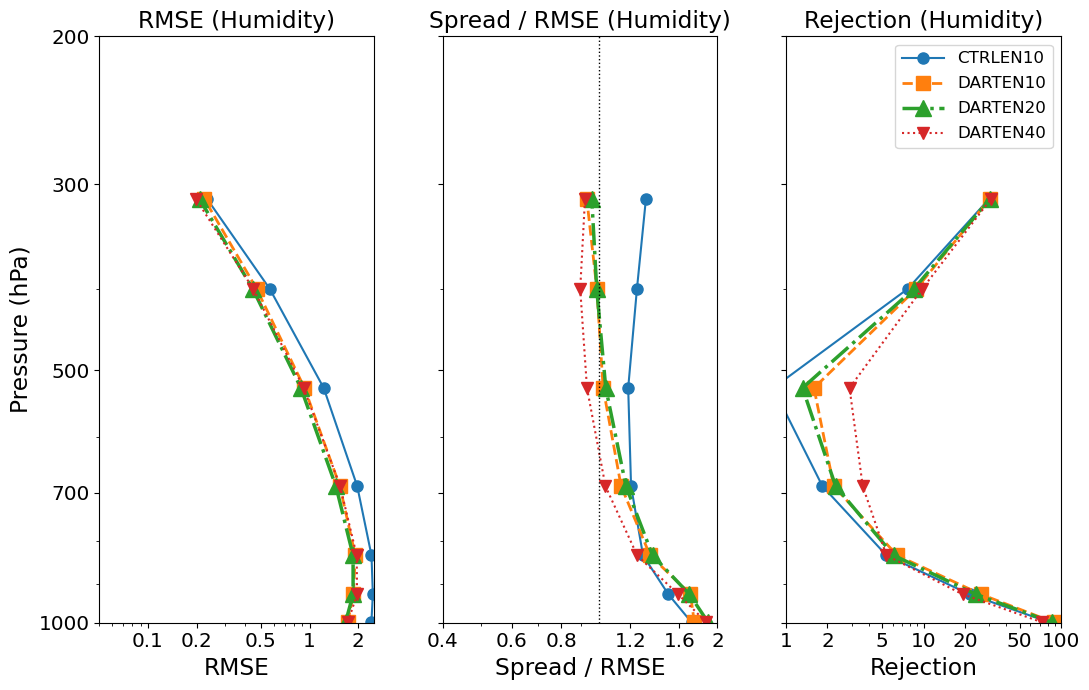

In [9]:
if __name__ == "__main__":
    top_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    out_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_dart"
    fig_path = "/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/figures/obs_diag"

    # === Configuration and inputs ===
    exp_info = get_dart_config()
    exp_dict = exp_info['experiments'] 
    exp_cfg  = exp_info['global']
    
    reg_dict = {
        'NH':      'Northern Hemisphere', 
        'SH':      'Southern Hemisphere', 
        'Tropics': 'Tropics', 
        'NA':      'North America',
        'Global':  'global'
    }
    
    region  = "SH"
    tunit = "2011-12-01"
    
    var_dict = {
        'U_WIND':      {'lev':'plev','vbound':[1.5,20], 'ybound':[5,1000],     'dtype': "VPguess"},
        'V_WIND':      {'lev':'plev','vbound':[1.5,20], 'ybound':[5,1000],     'dtype': "VPguess"},
        'Temperature': {'lev':'plev','vbound':[0.5,8], 'ybound':[5,1000],      'dtype': "VPguess"},
        'Humidity':    {'lev':'plev','vbound':[0.05,2.5], 'ybound':[200,1000], 'dtype': "VPguess"},
    }

    
    for varstr, varinfo in var_dict.items():
        
        varlev = varinfo['lev']
        vbound = varinfo['vbound']
        dtype = varinfo['dtype']
        ybound = varinfo['ybound']
        
        # === Initialize the diagnostics reader ===
        reader = DartObsDiagReader(exp_cfg)
    
        all_obs = reader.extract_obs_group()
    
        matches = [
            (group, lev, vv)
            for group, levels in all_obs.items()
            if "Satellite" not in group  # Exclude Satellite group
            for lev, variables in levels.items()
            if varlev.lower() in lev.lower()  # match level
            for vv in variables
            if varstr.lower() in vv.lower()   # match variable
        ]
    
        # Retrieve diagnostics data and pressure levels
        regnam =reg_dict.get(region)
        data_dict = dict()
        lev_dict = dict()
        for i in np.arange(len(matches)):
            vgroup, vlev, vname = matches[i]
            print(f'found match for variable {varstr} in {vgroup}: {vname}')
            var_dict = build_ts_var_dict(varstr, name=vname, y1aix=vbound[0], y1aix0=vbound[1])
            data_dict[vname],lev_dict[vname] = reader.extract_metrics_data(
                var=varstr,
                var_dict=var_dict[varstr],
                dtype=dtype,
                regnam=regnam,
                exp_dict=exp_dict
            )
        # calculate mean for all variables
        lev_str = check_flat_lev_consistency(lev_dict)
        # calculate mean for all variables
        diagnostic_keys = ['rmse','spread','rejection']
        data_dict = compute_experiment_means(data_dict,diagnostic_keys)
        var_dict = build_ts_var_dict(varstr, name=varstr, y1aix=vbound[0], y1aix0=vbound[1])
        # draw ts diagnostics
        print(f"\n>>> Processing variable '{varstr}' in region '{region}'")
        # Initialize the plotter class
        plotter = ObsDiagPlotter(
                var=varstr,
                var_dict=var_dict[varstr],
                data_dict=data_dict,
                fig_path=fig_path,
                plevstr=lev_str,
                regnam=regnam,
                hs=0.5,
                ws=0.5
        )
        # Generate vertical profile plot (no need to loop over levels)
        plotter.plot_metric_profile(
            variable = varstr, 
            show = False, save = True,  
            panel_width = 11, panel_height = 7, 
            xmin = vbound[0], xmax = vbound[1],
            ymin = ybound[0], ymax = ybound[1],
            yscale = "log"
        )        